<a href="https://colab.research.google.com/github/ferdinano/Aprendizaje_automatico_2026/blob/main/clase%208%20/%20Foro_clase_8_MCL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trabajaremos con el dataset disponible en campus el cual contiene los siguientes datos sobre clientes:

1.               purchase_freq_month — frecuencia de compras por mes (escala baja a media).

2.              avg_basket_usd — ticket/promedio por compra en USD (escala media a alta).

3.              time_on_site_min — tiempo de permanencia en el sitio (minutos).

4.             discount_sensitivity — sensibilidad a descuentos (0 a 1).

5.             returns_rate — tasa de devoluciones (0 a 0.8 aprox.).

Pista: algunas variables deberían ser escaladas antes de aplicar K-Means.

Qué se quiere descubrir con K-Means

●                    Objetivo: identificar cuántos segmentos latentes de clientes existen a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

●                    Qué patrones buscar:

o        Grupos con frecuencia alta pero ticket bajo y alta sensibilidad a descuentos.

o        Grupos con frecuencia baja pero ticket alto y baja sensibilidad (compras esporádicas pero grandes).

o        Grupos con tiempo en sitio y tasa de devoluciones diferenciados (p. ej., exploran mucho y devuelven más vs. exploran poco y devuelven menos).

●    Cómo validarlo:

o        Comparar k=2..6 usando método del codo para justificar qué valor de k es razonable.

o        Analizar los centroides por cluster para describir perfiles (p. ej., “Cluster 1: alta frecuencia + ticket medio + sensibilidad media, foco para promociones; Cluster 2: ticket alto + baja sensibilidad, foco en upselling premium”, etc.).

En esta instancia deberás compartir tu jupyter notebook en tu repositorio GIT.

# 1. Importación de librerías

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 2. Generación del dataset sintético

In [5]:
# lectura de los datos
clientes_df = pd.read_csv('/content/dataset_segmentacion_clientes.csv')
clientes_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


# Eploracion inicial

In [6]:
clientes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [7]:
clientes_df.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


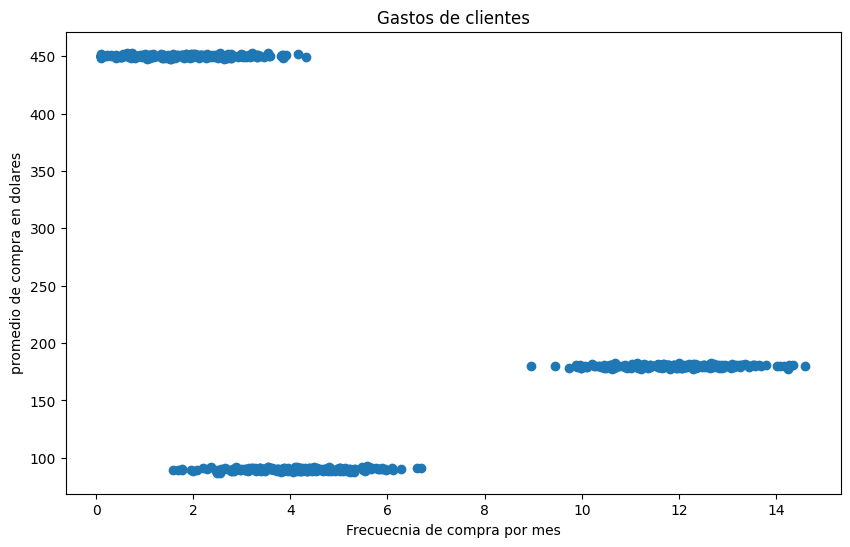

In [8]:
# Visulaizaciojn de los datos
plt.figure(figsize=(10, 6))
plt.scatter(clientes_df['purchase_freq_month'],
            clientes_df['avg_basket_usd']
            )
plt.xlabel('Frecuecnia de compra por mes')
plt.ylabel('promedio de compra en dolares')
plt.title('Gastos de clientes')
plt.show()

In [9]:
# Normalizacion de datos
# K-means utiliza disctancia eucliniana, por eso normalizamos.
scaler = StandardScaler()
clientes_scaled = scaler.fit_transform(clientes_df)

In [22]:
# Entrenamiento inicial de k-Means
kmeans_clientes = KMeans(# hiperparamentros
    n_clusters=3,# numeros de cluster que queiro que genere
    init='k-means++',# como se va a inicializar lso centriodes,
    n_init=10, # cantidad maxima de ejecuciones con centroides distintos, por defecto son 10, cuantas veces inicio de 0
    max_iter=300, # maximo de iteraciones
    random_state=42 #
    )
kmeans_clientes.fit(clientes_scaled)


KMeans(n_clusters=3, n_init=10, random_state=42)

In [23]:
from sklearn import cluster
# etiquetass de clusters
cluster_labels = kmeans_clientes.labels_ # aca se guarda las categorias del modelo
clientes_df['cluster'] = cluster_labels
clientes_df.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,2
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,1
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,2


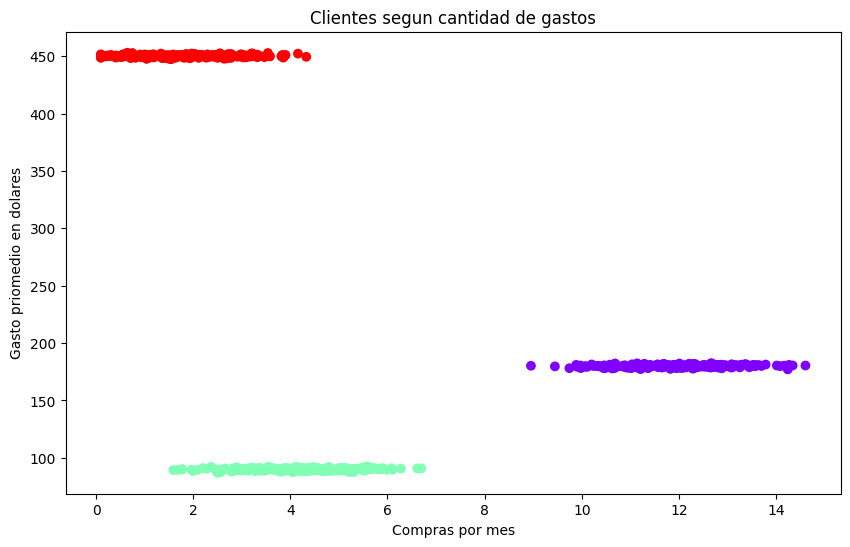

In [24]:
# Visualizacion de clusters
plt.figure(figsize=(10, 6))
plt.scatter(clientes_df['purchase_freq_month'],
            clientes_df['avg_basket_usd'],
            c=clientes_df['cluster'],
            cmap='rainbow'
            )
plt.xlabel('Compras por mes')
plt.ylabel('Gasto priomedio en dolares')
plt.title('Clientes segun cantidad de gastos')
plt.show()

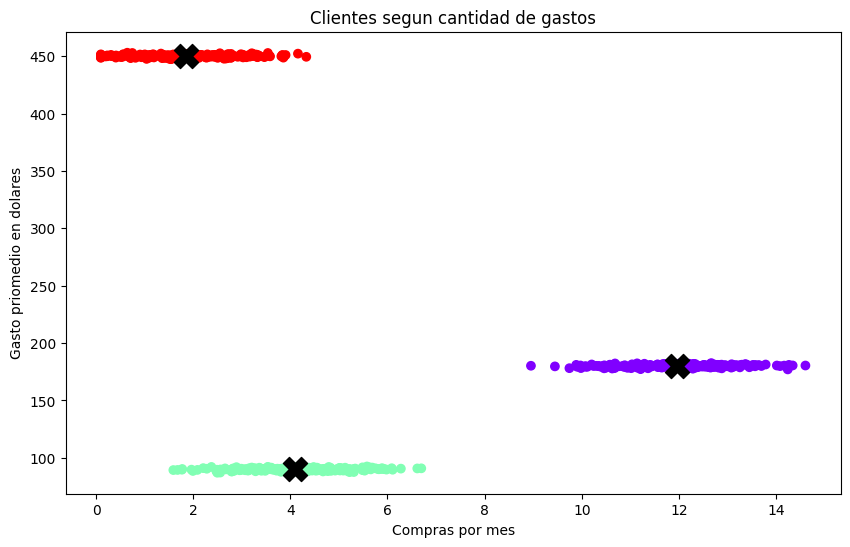

In [25]:
#visualizacion de centroides
centroides =scaler.inverse_transform(kmeans_clientes.cluster_centers_)
plt.figure(figsize=(10, 6))
plt.scatter(clientes_df['purchase_freq_month'],
            clientes_df['avg_basket_usd'],
            c=clientes_df['cluster'],
            cmap='rainbow'
            )
plt.scatter(centroides[:, 0],
            centroides[:, 1],
            marker='X',
            s=300,
            c='black')
plt.xlabel('Compras por mes')
plt.ylabel('Gasto priomedio en dolares')
plt.title('Clientes segun cantidad de gastos')
plt.show()

In [26]:
#interpretacion de clusters
clientes_df.groupby('cluster').mean()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
cluster,,,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461,0.046581,-0.039583
1,4.091883,89.957567,10.003793,0.379465,0.298761,-0.032045,-0.132205
2,1.846908,450.123746,5.973739,0.358088,0.375371,0.052026,0.123291


In [15]:
# como calcular el mejor cluster Inercia (metodo del codo) mide que tan agrupados estan los clsuter de acurdo a tus centroides,
# puedo identificar que tan coherentes son con sus grupos.
inercias = []
valores_k = range(1, 11)
for k in valores_k:
    modelo = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    modelo.fit(clientes_scaled)
    inercias.append(modelo.inertia_)

Text(0.5, 1.0, 'Metodo del Codo')

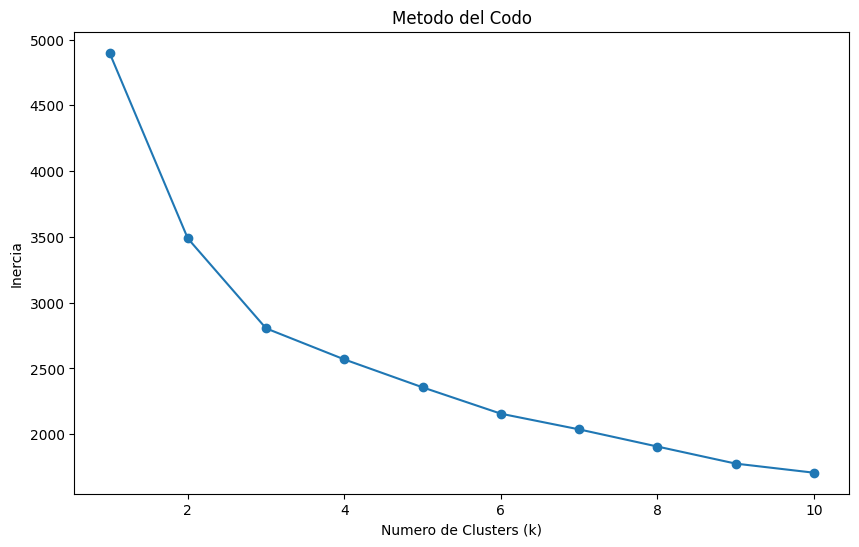

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del Codo')

In [17]:
# silhouette score que tan separados estan los cluster es mejor ya que puedo identificar los grupos
# que significan cada uno

In [27]:
silhouette_scores = []
valores_k = range(2, 11)
for k in valores_k:
    modelo = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    modelo.fit(clientes_scaled)
    silhouette_scores.append(silhouette_score(clientes_scaled, modelo.labels_))

Text(0.5, 1.0, 'Evaluacion de Silhouette Score')

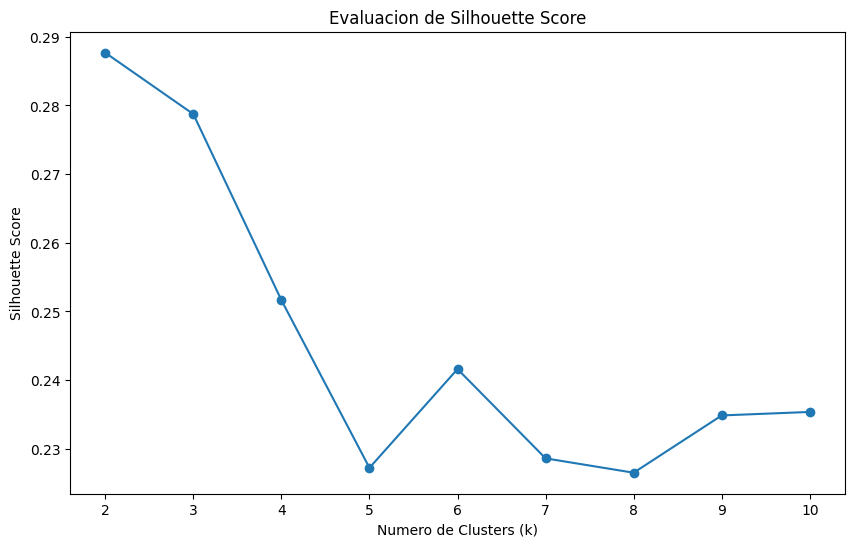

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(valores_k, silhouette_scores, marker='o')
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Evaluacion de Silhouette Score')

In [33]:
# prediccion de nuevos usuarios
nuevo_cliente = pd.DataFrame({
    "purchase_freq_month":[9.55],
    "avg_basket_usd":[150.5],
    "time_on_site_min":[5.98],
    "discount_sensitivity":[0.7],
    "returns_rate":[0.78],
    "noise_gauss":[-1.5],
    "noise_uniform":[2.5]
   })

nuevo_cliente_scaled = scaler.transform(nuevo_cliente)
cluster_prediccion = kmeans_clientes.predict(nuevo_cliente_scaled)
print(f'El nuevo usuario pertenece al cluster {cluster_prediccion[0]}')

El nuevo usuario pertenece al cluster 1


In [34]:
clientes_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,2
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,1
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,2
